In [1]:
import numpy as np
import time
import sys
import os

import numpy as np
import yfinance as fy
import QuantLib as ql
from typing import Optional, Union
import pandas as pd
import matplotlib.pyplot as plt
import multiprocess
import seaborn as sb
from tqdm import tqdm

from inception.instruments.constant_parameters import NOTES_PARAMETERS
from inception.utils import timer
from inception.quantlib_python import date_to_date
from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote

import mocaxextendpy.mocax_extend as me

In [2]:
parameters = NOTES_PARAMETERS['CIBC Multi Assets One']
start_date =  pd.Timestamp('2024-02-14')
days_interval = [(pd.Timestamp(d) - start_date).days for d in parameters['valuation dates']]
days_periods = list(zip([0] + [d + 1 for d in days_interval[:-1]], days_interval))
days_periods

[(0, 90),
 (91, 182),
 (183, 274),
 (275, 366),
 (367, 455),
 (456, 547),
 (548, 639),
 (640, 734),
 (735, 820),
 (821, 912),
 (913, 1006),
 (1007, 1098),
 (1099, 1185),
 (1186, 1279),
 (1280, 1370),
 (1371, 1461)]

In [8]:
def autocallable_note_pricer(x: list, additonal_data = None):
    """
    The Autocallable Notes pricer function wrapper, (adapts the original function signature to the signature expected by MoCaX)
    :param x: [stock A price, stock B price, stock C price, days after the start date]
    :param additional_data: extra parameters required by MoCaX
    """
    import numpy as np
    import pandas as pd
    from inception.instruments.constant_parameters import NOTES_PARAMETERS
    from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote
    
    start_date = '2024-02-14'
    # Input parameters:
    spot_price = np.array(x[:3])
    eval_date = pd.Timestamp(start_date) + pd.Timedelta(days=x[3])
    
    corr_matrix = np.array(
        [[1.        , 0.96432854, 0.80799003],
        [0.96432854, 1.        , 0.8267037 ],
        [0.80799003, 0.8267037 , 1.        ]]
    )
    issued_price = [382.82, 494.08, 142.86]
    index_vol = [0.16, 0.16, 0.16]
    risk_free_rate = 0.05
    path_num = 100_000
    d_s = 0.02
    parameters = NOTES_PARAMETERS['CIBC Multi Assets One']
    simulator = ReferenceMultiIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, corr_matrix, d_s)
    notes = MultiAssetAutoCallableNote(eval_date,
                                       ['A', 'B', 'C'],
                                       simulator, 
                                       parameters['valuation dates'],
                                       parameters['coupon dates'],
                                       parameters['call dates'],
                                       coupon_barrier=parameters['coupon barrier'],
                                       call_barrier=parameters['call barrier'],
                                       principal_barrier=parameters['principal barrier'],
                                       coupon_amount=parameters['coupon amount'],
                                       free_rate=risk_free_rate,
                                       n_paths=path_num)

    
    return notes.value

## Validation

In [9]:
## -- Deserialization
time_bucket = 15
mocax_extend = me.MocaxExtend.deserialize(f"./chebyshev_database/autocallable_tensor_extension_{time_bucket}.pickle")

In [10]:
mocax_extend.intervals

[[76.56400000000001, 574.23],
 [98.816, 741.12],
 [28.572000000000003, 214.29000000000002],
 [1371, 1461]]

In [13]:
func = lambda x: np.random.uniform(x * 0.2, x * 1.5)
value_m = []
value_p = []
issued_price = [382.82, 494.08, 142.86]

for _ in range(100):
    x = [func(d) for d in issued_price] + [np.random.choice(np.arange(*days_periods[time_bucket]))]
    value_m.append(mocax_extend.cheb_tensor_evals(np.array([x]))[0])
    value_p.append(autocallable_note_pricer(x))

Maximum error: 9.31174
Mean error: 1.06466


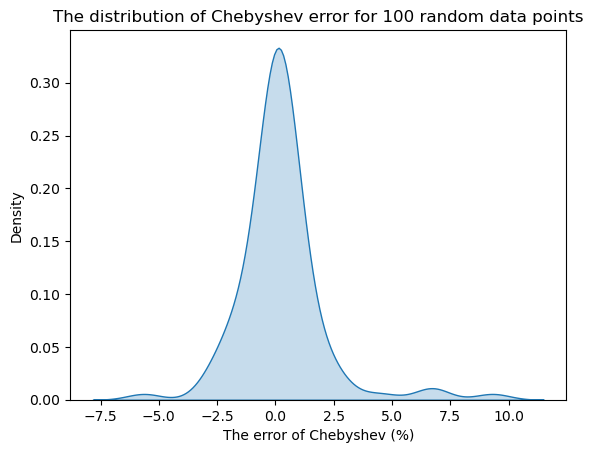

In [14]:
error_2 = (np.array(value_p) - np.array(value_m)) / np.array(value_p) * 100
sb.kdeplot(error_2,fill=True)
plt.title('The distribution of Chebyshev error for 100 random data points')
plt.xlabel('The error of Chebyshev (%)')

# -- Empirical error
error_sup = max(abs(error_2))
error_mean = abs(error_2).mean()

print(f"Maximum error: {error_sup:.5f}")
print(f"Mean error: {error_mean:.5f}")

In [31]:
issued_price = [382.82, 494.08, 142.86]
calc_dates = np.arange(1280, 1370, 3)

price_percentage = np.arange(0.5, 1.5, 0.05)
values_mocax = []
values_func = []
for i, p in tqdm(enumerate(price_percentage)):
    values_mocax.append([])
    values_func.append([])
    for d in calc_dates:
        x = [price * p for price in issued_price] + [d]
        values_mocax[i].append(mocax_extend.cheb_tensor_evals(np.array([x]))[0])
        values_func[i].append(autocallable_note_pricer(x))


20it [04:03, 12.17s/it]


C:\Users\TY482JM\AppData\Local\Temp\ipykernel_3744\1018823744.py:5: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(121, projection='3d')


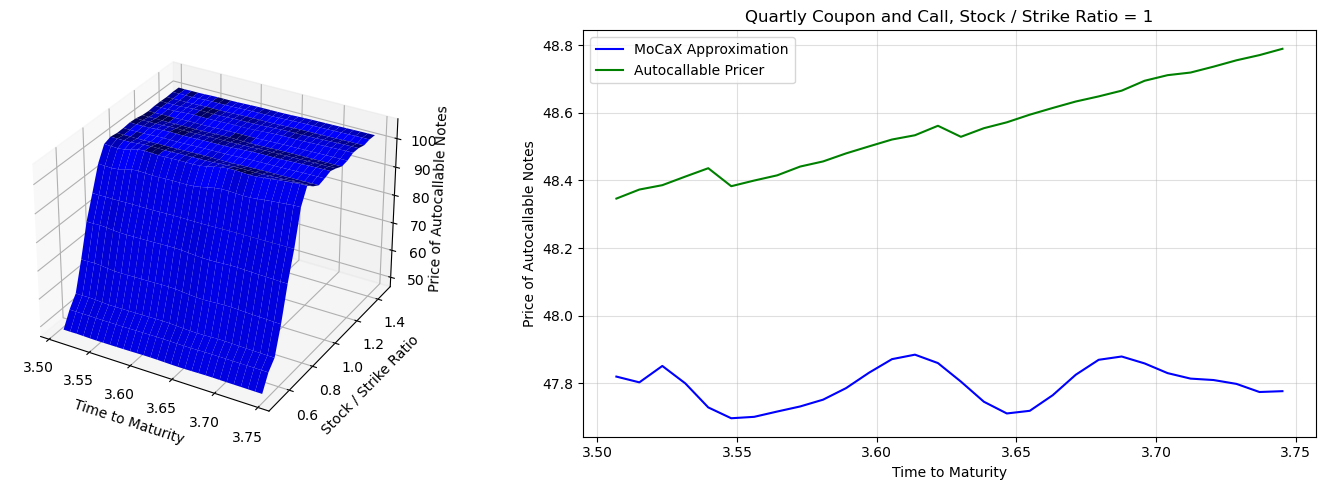

In [40]:
fig = plt.figure(figsize =(15, 5))

plt.subplot(121)
# ax = plt.axes(projection ='3d')
ax = plt.subplot(121, projection='3d')

times = [d / 365 for d in calc_dates]

x1,y1= np.meshgrid(times, price_percentage)

ax.plot_surface(x1, y1, np.array(values_mocax), color='blue')

# ax.plot_surface(x1, y1, np.array(values_func), color='green')

ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Stock / Strike Ratio')
ax.set_zlabel('Price of Autocallable Notes', rotation=90)
ax.zaxis.labelpad=-0.7

ax2 = plt.subplot(122)
ax2.plot(times, values_mocax[0], label='MoCaX Approximation', color='blue')
ax2.plot(times, values_func[0], label='Autocallable Pricer', color='green')
ax2.grid(alpha=0.4)
ax2.set_xlabel('Time to Maturity')
ax2.set_ylabel('Price of Autocallable Notes')
ax2.legend()
ax2.set_title('Quartly Coupon and Call, Stock / Strike Ratio = 1')
plt.tight_layout();

C:\Users\TY482JM\AppData\Local\Temp\ipykernel_3744\3517914121.py:5: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(121, projection='3d')


Text(0.5, 0, 'The error of Chebyshev (%)')

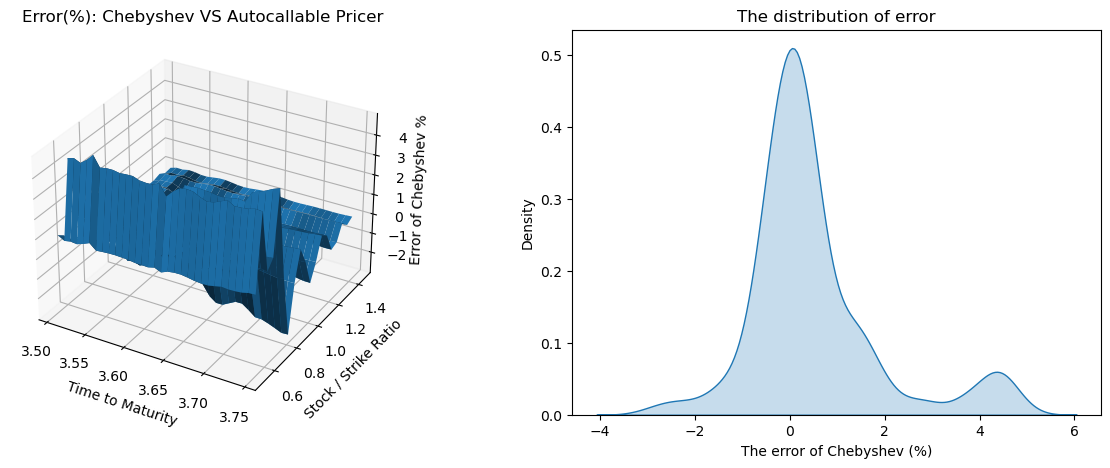

In [33]:
fig = plt.figure(figsize =(15, 5))

plt.subplot(121)
# ax = plt.axes(projection ='3d')
ax = plt.subplot(121, projection='3d')

times = [d / 365 for d in calc_dates]

x1,y1= np.meshgrid(times, price_percentage)
error = (np.array(values_func) - np.array(values_mocax)) / np.array(values_func) * 100

ax.plot_surface(x1, y1, error)
ax.set_title('Error(%): Chebyshev VS Autocallable Pricer')


ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Stock / Strike Ratio')
ax.set_zlabel('Error of Chebyshev %', rotation=90)
ax.zaxis.labelpad=-0.7

ax2 = plt.subplot(122)
sb.kdeplot(error.flatten(),fill=True)
plt.title('The distribution of error')
plt.xlabel('The error of Chebyshev (%)')

In [15]:
15 * 15 * 15 * 7

23625